In [2]:
# 01. LOAD CLEANED DATASETS

import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

print("                 LOADING CLEANED DATASETS")

# 2. Load Cleaned Datasets

customers = pd.read_csv(r"C:\Users\Rajan\OneDrive\Desktop\ecommerce-business-intelligence\Data\cleaned\customers_clean.csv")

orders = pd.read_csv(r"C:\Users\Rajan\OneDrive\Desktop\ecommerce-business-intelligence\Data\cleaned\orders_clean.csv")

order_items = pd.read_csv(r"C:\Users\Rajan\OneDrive\Desktop\ecommerce-business-intelligence\Data\cleaned\order_items_clean.csv")

payments =  pd.read_csv(r"C:\Users\Rajan\OneDrive\Desktop\ecommerce-business-intelligence\Data\cleaned\payments_clean.csv")

reviews =  pd.read_csv(r"C:\Users\Rajan\OneDrive\Desktop\ecommerce-business-intelligence\Data\cleaned\reviews_clean.csv")

products =  pd.read_csv(r"C:\Users\Rajan\OneDrive\Desktop\ecommerce-business-intelligence\Data\cleaned\products_clean.csv")

sellers =  pd.read_csv(r"C:\Users\Rajan\OneDrive\Desktop\ecommerce-business-intelligence\Data\cleaned\sellers_clean.csv")

geolocation =  pd.read_csv(r"C:\Users\Rajan\OneDrive\Desktop\ecommerce-business-intelligence\Data\cleaned\geolocation_clean.csv")

category_translation =  pd.read_csv(r"C:\Users\Rajan\OneDrive\Desktop\ecommerce-business-intelligence\Data\cleaned\category_translation_clean.csv")



                 LOADING CLEANED DATASETS


In [3]:
# 3.1 DATASET OVERVIEW

datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products,
    "Sellers": sellers,
    "Geolocation": geolocation,
    "Category Translation": category_translation
}

overview = []

for name, df in datasets.items():
    overview.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

overview_df = pd.DataFrame(overview)

display(overview_df)

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Customers,99441,5,0,0
1,Orders,99441,8,4908,0
2,Order Items,112650,7,0,0
3,Payments,103886,5,0,0
4,Reviews,99224,7,29,0
5,Products,32951,9,0,0
6,Sellers,3095,4,0,0
7,Geolocation,738332,5,0,0
8,Category Translation,71,2,0,0


In [11]:
for name, df in datasets.items():

   
    print(name.upper())
    print("-" * 70)

    column_info = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values,
        "Missing Values": df.isnull().sum().values,
        "Unique Values": df.nunique().values
    })

    display(column_info)

CUSTOMERS
----------------------------------------------------------------------


,Column,Data Type,Missing Values,Unique Values
0,customer_id,object,0,99441
1,customer_unique_id,object,0,96096
2,customer_zip_code_prefix,int64,0,14994
3,customer_city,object,0,4119
4,customer_state,object,0,27


ORDERS
----------------------------------------------------------------------


,Column,Data Type,Missing Values,Unique Values
0,order_id,object,0,99441
1,customer_id,object,0,99441
2,order_status,object,0,8
3,order_purchase_timestamp,object,0,98875
4,order_approved_at,object,160,90733
5,order_delivered_carrier_date,object,1783,81018
6,order_delivered_customer_date,object,2965,95664
7,order_estimated_delivery_date,object,0,459


ORDER ITEMS
----------------------------------------------------------------------


...

,Column,Data Type,Missing Values,Unique Values
0,seller_id,object,0,3095
1,seller_zip_code_prefix,int64,0,2246
2,seller_city,object,0,611
3,seller_state,object,0,23


GEOLOCATION
----------------------------------------------------------------------


,Column,Data Type,Missing Values,Unique Values
0,geolocation_zip_code_prefix,int64,0,19015
1,geolocation_lat,float64,0,717349
2,geolocation_lng,float64,0,717613
3,geolocation_city,object,0,8011
4,geolocation_state,object,0,27


CATEGORY TRANSLATION
----------------------------------------------------------------------


,Column,Data Type,Missing Values,Unique Values
0,product_category_name,object,0,71
1,product_category_name_english,object,0,71


In [10]:
# 4.1 DESCRIPTIVE STATISTICS

for name, df in datasets.items():

    numeric_columns = df.select_dtypes(include=np.number)

    if not numeric_columns.empty:

        print("\n" + "-" * 70)
        print(f"{name.upper()} — DESCRIPTIVE STATISTICS")
        print("-" * 70)

        display(numeric_columns.describe().T)


----------------------------------------------------------------------
CUSTOMERS — DESCRIPTIVE STATISTICS
----------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
customer_zip_code_prefix,99441.0,35137.474583,29797.938996,1003.0,11347.0,24416.0,58900.0,99990.0



----------------------------------------------------------------------
ORDER ITEMS — DESCRIPTIVE STATISTICS
----------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
order_item_id,112650.0,1.197834,0.705124,1.00,1.00,1.00,1.00,21.00
price,112650.0,120.653739,183.633928,0.85,39.90,74.99,134.90,6735.00
freight_value,112650.0,19.990320,15.806405,0.00,13.08,16.26,21.15,409.68



----------------------------------------------------------------------
PAYMENTS — DESCRIPTIVE STATISTICS
----------------------------------------------------------------------


...

,count,mean,std,min,25%,50%,75%,max
product_name_lenght,32951.0,48.523656,10.156155,5.0,42.0,51.0,57.0,76.0
product_description_lenght,32951.0,768.227945,629.658469,4.0,344.0,595.0,961.0,3992.0
product_photos_qty,32951.0,2.166975,1.728063,1.0,1.0,1.0,3.0,20.0
product_weight_g,32951.0,2276.461777,4281.888156,2.0,300.0,700.0,1900.0,40425.0
product_length_cm,32951.0,30.814725,16.914005,7.0,18.0,25.0,38.0,105.0
product_height_cm,32951.0,16.937422,13.637175,2.0,8.0,13.0,21.0,105.0
product_width_cm,32951.0,23.196534,12.078707,6.0,15.0,20.0,30.0,118.0



----------------------------------------------------------------------
SELLERS — DESCRIPTIVE STATISTICS
----------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
seller_zip_code_prefix,3095.0,32291.059451,32713.45383,1001.0,7093.5,14940.0,64552.5,99730.0



----------------------------------------------------------------------
GEOLOCATION — DESCRIPTIVE STATISTICS
----------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
geolocation_zip_code_prefix,738332.0,38316.086800,30632.496675,1001.000000,12600.000000,29144.000000,65950.000000,99990.000000
geolocation_lat,738332.0,-20.998353,5.892315,-36.605374,-23.603061,-22.873588,-19.923336,45.065933
geolocation_lng,738332.0,-46.461098,4.393705,-101.466766,-48.867822,-46.647278,-43.836974,121.105394


ORDER STATUS DISTRIBUTION


,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


,order_status,percentage
0,delivered,97.02
1,shipped,1.11
2,canceled,0.63
3,unavailable,0.61
4,invoiced,0.32
5,processing,0.30
6,created,0.01
7,approved,0.00


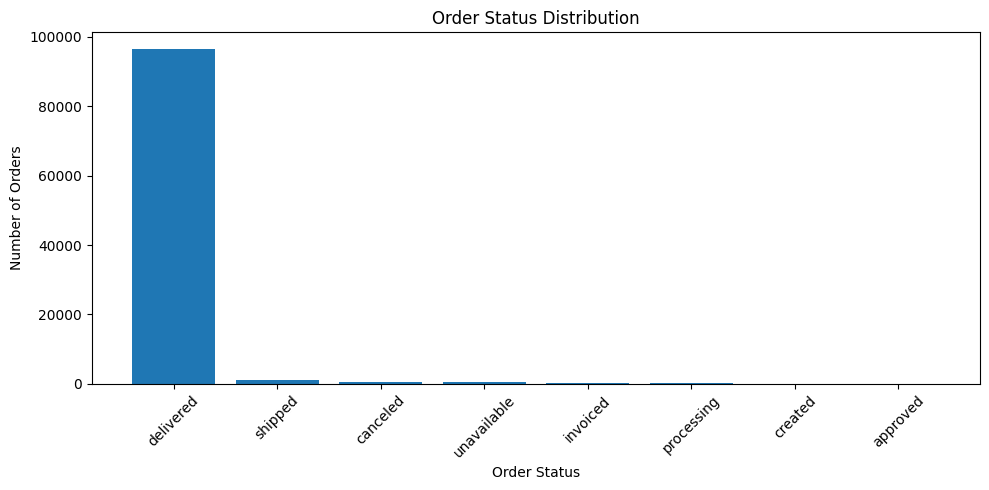

In [12]:
# 4 ORDER ANALYSIS
# 4.1 ORDER STATUS DISTRIBUTION

order_status = orders["order_status"].value_counts().reset_index()
order_status.columns = ["order_status", "order_count"]

print("ORDER STATUS DISTRIBUTION")
print("=" * 70)

display(order_status)

order_status_pct = (
    orders["order_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

order_status_pct.columns = ["order_status", "percentage"]

display(order_status_pct)

plt.figure(figsize=(10, 5))
plt.bar(order_status["order_status"], order_status["order_count"])
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,order_month,order_count
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


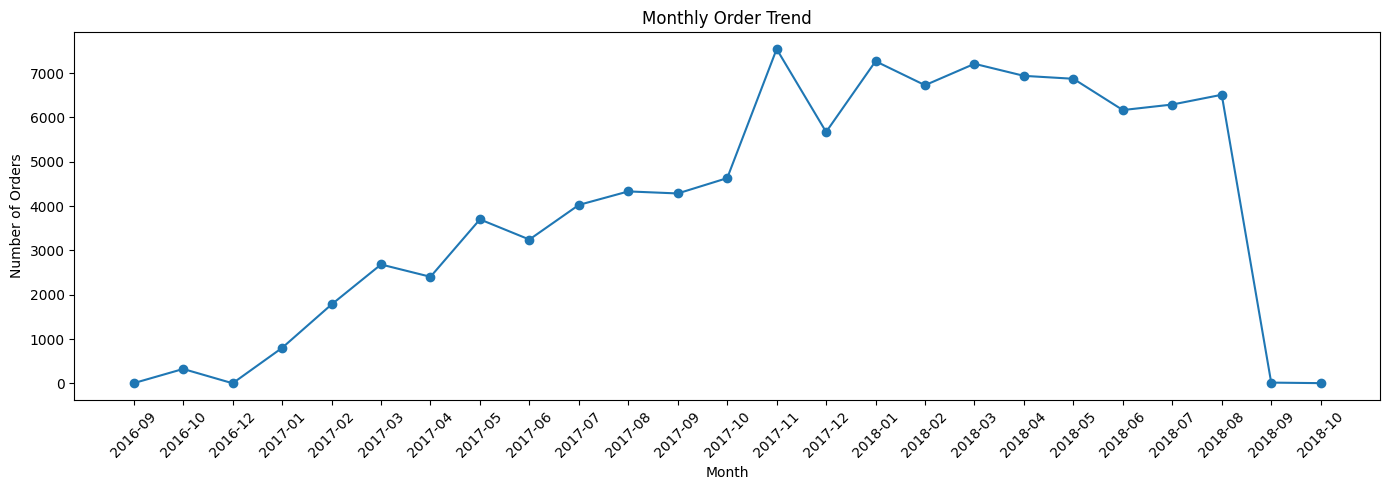

In [13]:

# 4.2 MONTHLY ORDER TREND

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

orders["order_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

monthly_orders = (
    orders.groupby("order_month")
    .size()
    .reset_index(name="order_count")
)

monthly_orders["order_month"] = monthly_orders["order_month"].astype(str)

display(monthly_orders)

plt.figure(figsize=(14, 5))
plt.plot(
    monthly_orders["order_month"],
    monthly_orders["order_count"],
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# 5 SALES & REVENUE ANALYSIS
# 5.1 TOTAL SALES

total_sales = order_items["price"].sum()

print("SALES & REVENUE ANALYSIS")

print(f"Total Sales Revenue : {total_sales:,.2f}")

SALES & REVENUE ANALYSIS
Total Sales Revenue : 13,591,643.70


In [16]:
# 5.2 AVERAGE ORDER VALUE

order_revenue = (
    order_items.groupby("order_id")["price"]
    .sum()
)

average_order_value = order_revenue.mean()

print(f"Average Order Value : {average_order_value:,.2f}")

Average Order Value : 137.75


,order_month,revenue
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02
5,2017-03,374344.30
6,2017-04,359927.23
7,2017-05,506071.14
8,2017-06,433038.60
9,2017-07,498031.48


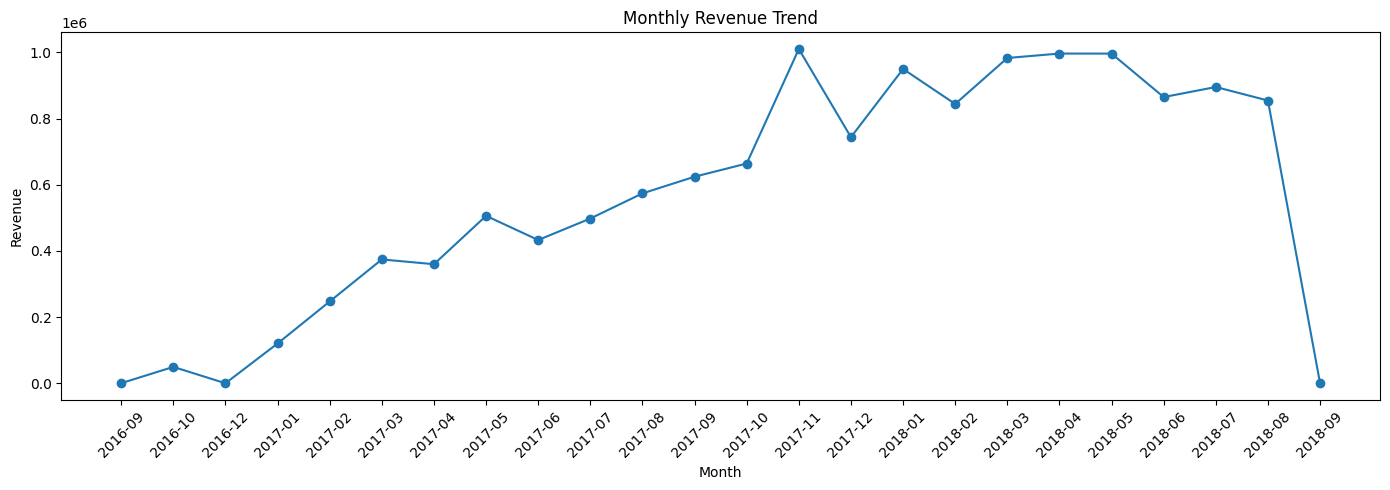

In [17]:
# 5.3 MONTHLY REVENUE

order_items_analysis = order_items.merge(
    orders[["order_id", "order_purchase_timestamp"]],
    on="order_id",
    how="left"
)

order_items_analysis["order_month"] = (
    order_items_analysis["order_purchase_timestamp"]
    .dt.to_period("M")
)

monthly_revenue = (
    order_items_analysis
    .groupby("order_month")["price"]
    .sum()
    .reset_index(name="revenue")
)

monthly_revenue["order_month"] = monthly_revenue["order_month"].astype(str)

display(monthly_revenue)

plt.figure(figsize=(14, 5))
plt.plot(
    monthly_revenue["order_month"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,category,revenue
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32
5,moveis_decoracao,729762.49
6,cool_stuff,635290.85
7,utilidades_domesticas,632248.66
8,automotivo,592720.11
9,ferramentas_jardim,485256.46


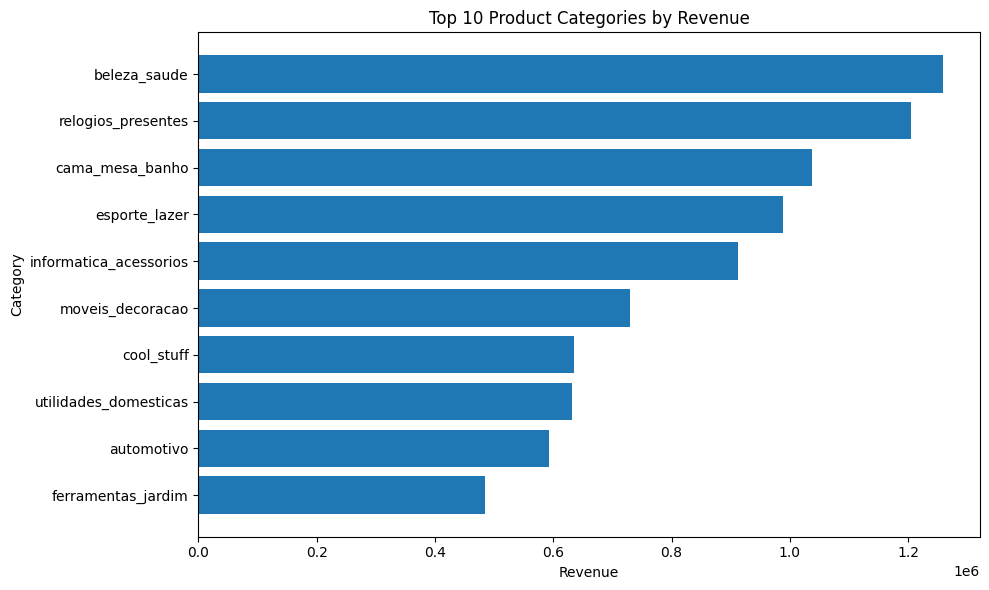

In [18]:
# 6 PRODUCT & CATEGORY ANALYSIS
# 6.1 TOP PRODUCT CATEGORIES

category_sales = order_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

top_categories = (
    category_sales
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_categories.columns = ["category", "revenue"]

display(top_categories)

plt.figure(figsize=(10, 6))
plt.barh(
    top_categories["category"].iloc[::-1],
    top_categories["revenue"].iloc[::-1]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [19]:
# 6.2 TOP PRODUCTS BY REVENUE

top_products = (
    order_items
    .groupby("product_id")
    .agg(
        total_revenue=("price", "sum"),
        units_sold=("order_item_id", "count")
    )
    .sort_values("total_revenue", ascending=False)
    .head(10)
    .reset_index()
)

display(top_products)

,product_id,total_revenue,units_sold
0,bb50f2e236e5eea0100680137654686c,63885.00,195
1,6cdd53843498f92890544667809f1595,54730.20,156
2,d6160fb7873f184099d9bc95e30376af,48899.34,35
3,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51,343
4,99a4788cb24856965c36a24e339b6058,43025.56,488
5,3dd2a17168ec895c781a9191c1e95ad7,41082.60,274
6,25c38557cf793876c5abdd5931f922db,38907.32,38
7,5f504b3a1c75b73d6151be81eb05bdc9,37733.90,63
8,53b36df67ebb7c41585e8d54d6772e08,37683.42,323
9,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90,527


,state,customer_count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


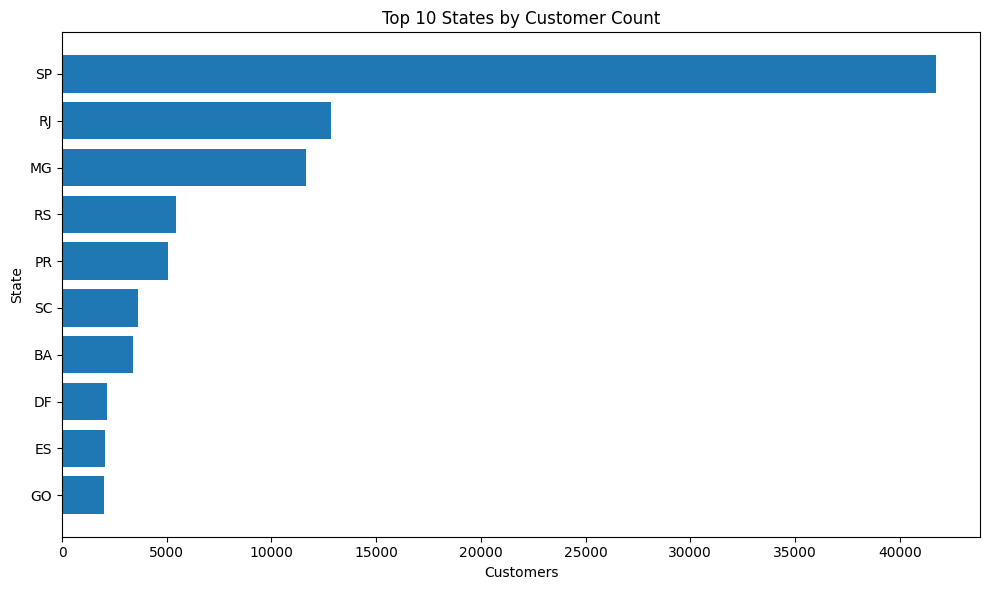

In [20]:
# 7 CUSTOMER ANALYSIS
# 7.1 CUSTOMER DISTRIBUTION BY STATE

customer_state = (
    customers["customer_state"]
    .value_counts()
    .head(10)
    .reset_index()
)

customer_state.columns = ["state", "customer_count"]

display(customer_state)

plt.figure(figsize=(10, 6))
plt.barh(
    customer_state["state"].iloc[::-1],
    customer_state["customer_count"].iloc[::-1]
)

plt.title("Top 10 States by Customer Count")
plt.xlabel("Customers")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [21]:
# 7.2 CUSTOMER SPENDING

customer_orders = orders[
    ["order_id", "customer_id"]
].merge(
    order_items[["order_id", "price"]],
    on="order_id",
    how="inner"
)

customer_spending = (
    customer_orders
    .groupby("customer_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 Customers by Spending")

display(
    customer_spending.head(10).reset_index(
        name="total_spending"
    )
)

Top 10 Customers by Spending


,customer_id,total_spending
0,1617b1357756262bfa56ab541c47bc16,13440.0
1,ec5b2ba62e574342386871631fafd3fc,7160.0
2,c6e2731c5b391845f6800c97401a43a9,6735.0
3,f48d464a0baaea338cb25f816991ab1f,6729.0
4,3fd6777bbce08a352fddd04e4a7cc8f6,6499.0
5,05455dfa7cd02f13d132aa7a6a9729c6,5934.6
6,df55c14d1476a9a3467f131269c2477f,4799.0
7,24bbf5fd2f2e1b359ee7de94defc4a15,4690.0
8,e0a2412720e9ea4f26c1ac985f6a7358,4599.9
9,3d979689f636322c62418b6346b1c6d2,4590.0


,seller_id,revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63
1,53243585a1d6dc2643021fd1853d8905,222776.05
2,4a3ca9315b744ce9f8e9374361493884,200472.92
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03
4,7c67e1448b00f6e969d365cea6b010ab,187923.89
5,7e93a43ef30c4f03f38b393420bc753a,176431.87
6,da8622b14eb17ae2831f4ac5b9dab84a,160236.57
7,7a67c85e85bb2ce8582c35f2203ad736,141745.53
8,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55
9,955fee9216a65b617aa5c0531780ce60,135171.70


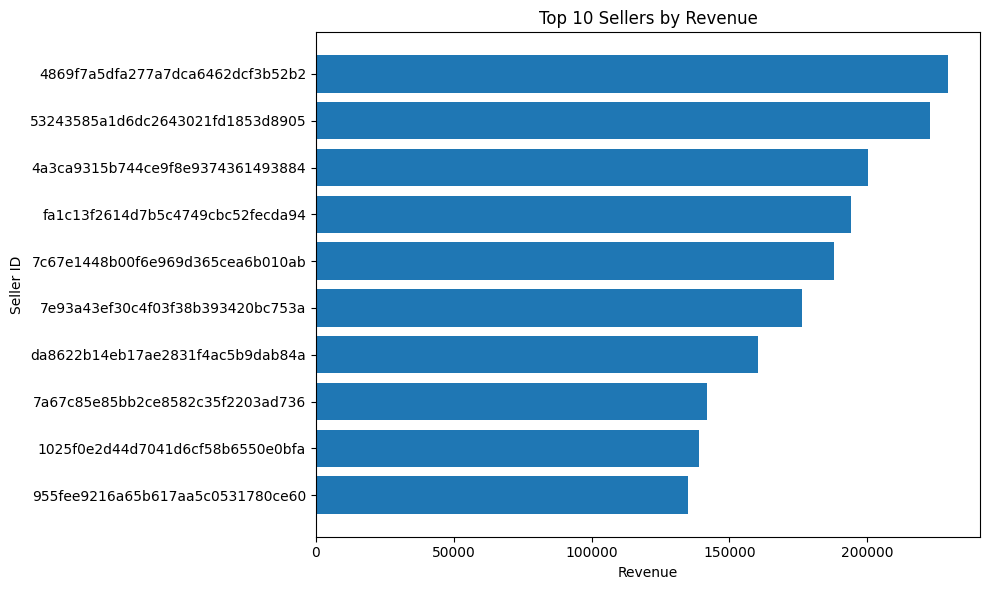

In [22]:
# 8 SELLER ANALYSIS
# 8.1 TOP SELLERS BY REVENUE

seller_sales = (
    order_items
    .groupby("seller_id")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

seller_sales.columns = ["seller_id", "revenue"]

display(seller_sales)

plt.figure(figsize=(10, 6))
plt.barh(
    seller_sales["seller_id"].astype(str).iloc[::-1],
    seller_sales["revenue"].iloc[::-1]
)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller ID")
plt.tight_layout()
plt.show()

,payment_type,payment_count
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


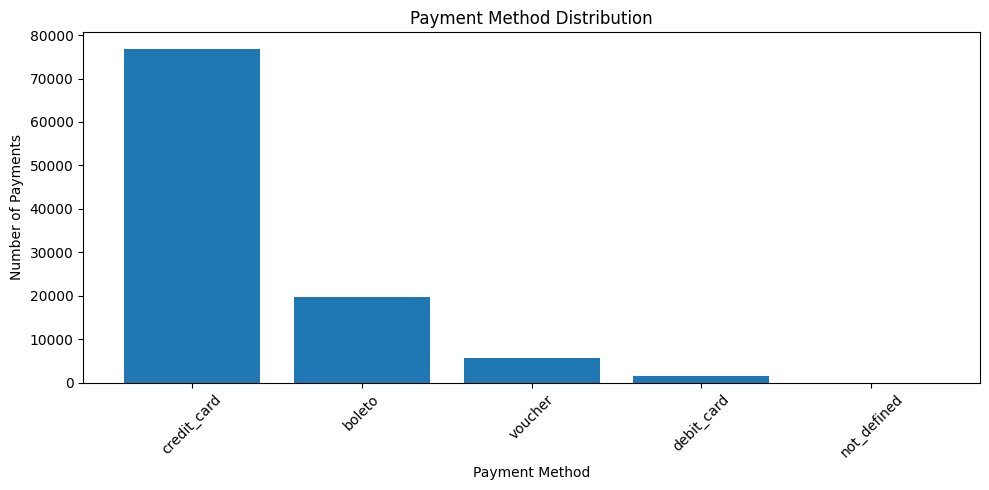

In [23]:
# 7.9 PAYMENT ANALYSIS
# 7.9.1 PAYMENT METHOD DISTRIBUTION

payment_methods = (
    payments["payment_type"]
    .value_counts()
    .reset_index()
)

payment_methods.columns = ["payment_type", "payment_count"]

display(payment_methods)

plt.figure(figsize=(10, 5))
plt.bar(
    payment_methods["payment_type"],
    payment_methods["payment_count"]
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Payments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,payment_type,payment_count
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


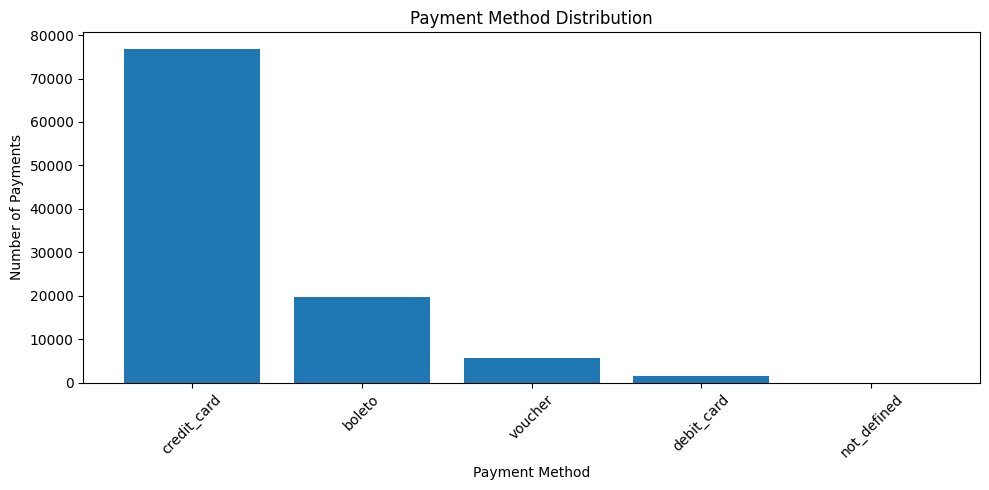

In [24]:
# 9 PAYMENT ANALYSIS
# 9.1 PAYMENT METHOD DISTRIBUTION

payment_methods = (
    payments["payment_type"]
    .value_counts()
    .reset_index()
)

payment_methods.columns = ["payment_type", "payment_count"]

display(payment_methods)

plt.figure(figsize=(10, 5))
plt.bar(
    payment_methods["payment_type"],
    payment_methods["payment_count"]
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Payments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# 7.9.2 PAYMENT VALUE ANALYSIS

payment_summary = payments["payment_value"].describe()

display(payment_summary.to_frame("payment_value"))

,payment_value
count,103886.000000
mean,154.100380
std,217.494064
min,0.000000
25%,56.790000
50%,100.000000
75%,171.837500
max,13664.080000


In [26]:
# 9.3 PAYMENT INSTALLMENTS

installments = (
    payments["payment_installments"]
    .value_counts()
    .sort_index()
    .reset_index()
)

installments.columns = [
    "installments",
    "payment_count"
]

display(installments.head(20))

,installments,payment_count
0,0,2
1,1,52546
2,2,12413
3,3,10461
4,4,7098
5,5,5239
6,6,3920
7,7,1626
8,8,4268
9,9,644


,review_score,review_count
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


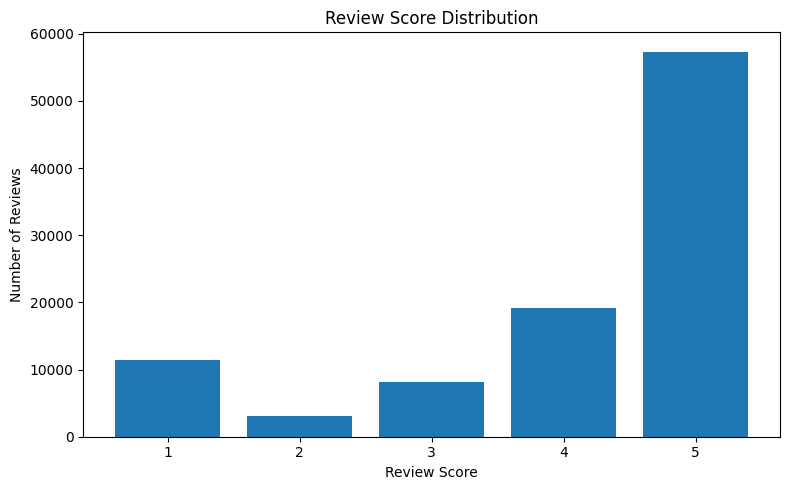

In [27]:
# 10 REVIEW & RATING ANALYSIS
# 10.1 REVIEW SCORE DISTRIBUTION

review_scores = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

review_scores.columns = ["review_score", "review_count"]

display(review_scores)

plt.figure(figsize=(8, 5))
plt.bar(
    review_scores["review_score"],
    review_scores["review_count"]
)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

In [29]:
#10.2 AVERAGE REVIEW SCORE

average_review_score = reviews["review_score"].mean()

print(f"Average Review Score : {average_review_score:.2f}")

Average Review Score : 4.09


In [30]:
#11 DELIVERY PERFORMANCE
#11.1 ACTUAL DELIVERY TIME

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"],
    errors="coerce"
)

delivery_data = orders.dropna(
    subset=[
        "order_purchase_timestamp",
        "order_delivered_customer_date"
    ]
).copy()

delivery_data["delivery_days"] = (
    delivery_data["order_delivered_customer_date"]
    - delivery_data["order_purchase_timestamp"]
).dt.total_seconds() / 86400

print("Delivery Time Statistics")

display(
    delivery_data["delivery_days"].describe().to_frame(
        "delivery_days"
    )
)

Delivery Time Statistics


,delivery_days
count,96476.000000
mean,12.558702
std,9.546530
min,0.533414
25%,6.766403
50%,10.217755
75%,15.720327
max,209.628611


In [31]:
# 12 GEOGRAPHIC ANALYSIS
# 12.1 CUSTOMER STATE ANALYSIS

customer_states = (
    customers["customer_state"]
    .value_counts()
    .reset_index()
)

customer_states.columns = ["state", "customers"]

display(customer_states)

,state,customers
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


In [32]:
# 7.12.2 SELLER STATE ANALYSIS

seller_states = (
    sellers["seller_state"]
    .value_counts()
    .reset_index()
)

seller_states.columns = ["state", "sellers"]

display(seller_states)

,state,sellers
0,SP,1849
1,PR,349
2,MG,244
3,SC,190
4,RJ,171
5,RS,129
6,GO,40
7,DF,30
8,ES,23
9,BA,19


In [34]:
# 14 CORRELATION ANALYSIS

numeric_order_items = order_items.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_order_items.corr()

display(correlation_matrix.round(2))

,order_item_id,price,freight_value
order_item_id,1.00,-0.06,-0.03
price,-0.06,1.00,0.41
freight_value,-0.03,0.41,1.00


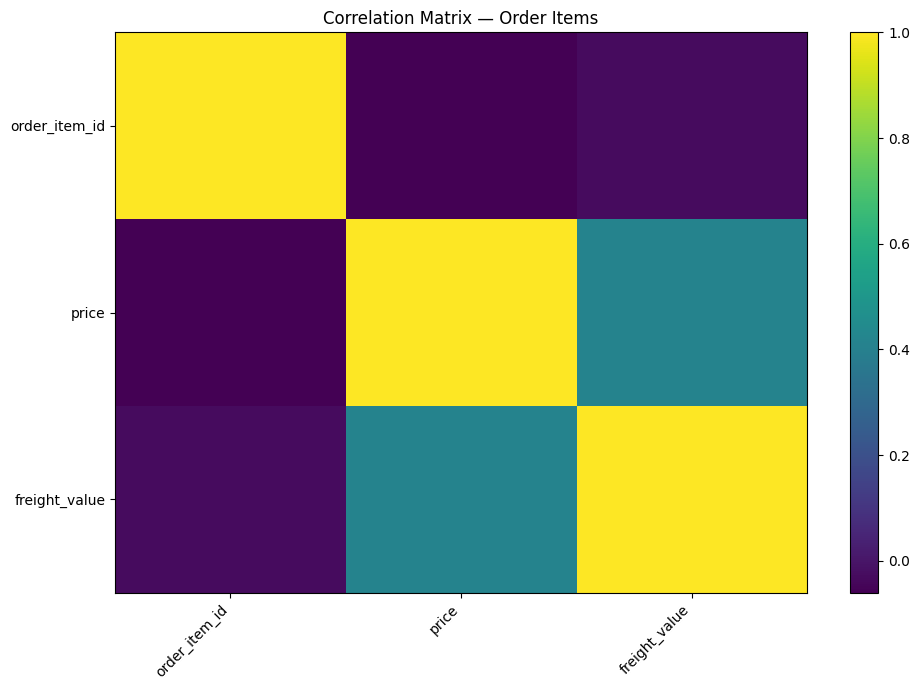

In [35]:
plt.figure(figsize=(10, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix — Order Items")
plt.tight_layout()
plt.show()

In [5]:
# 15 BUSINESS KPI ANALYSIS

total_orders = orders["order_id"].nunique()

total_customers = customers["customer_unique_id"].nunique()

total_products = products["product_id"].nunique()

total_sellers = sellers["seller_id"].nunique()

total_revenue = payments["payment_value"].sum()

total_revenue = payments["payment_value"].sum()

total_orders = orders["order_id"].nunique()

average_order_value = total_revenue / total_orders

average_review_score = reviews["review_score"].mean()

print("=" * 70)
print("                    BUSINESS KPI SUMMARY")
print("=" * 70)

print(f"Total Orders          : {total_orders:,}")
print(f"Total Customers       : {total_customers:,}")
print(f"Total Products        : {total_products:,}")
print(f"Total Sellers         : {total_sellers:,}")
print(f"Total Revenue         : {total_revenue:,.2f}")
print(f"Average Order Value   : {average_order_value:,.2f}")
print(f"Average Review Score  : {average_review_score:.2f}")

                    BUSINESS KPI SUMMARY
Total Orders          : 99,441
Total Customers       : 96,096
Total Products        : 32,951
Total Sellers         : 3,095
Total Revenue         : 16,008,872.12
Average Order Value   : 160.99
Average Review Score  : 4.09
